In [5]:
# Set a random seed for reproducibility in TensorFlow
import os
import random
import tensorflow as tf
import numpy as np

def set_seed(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

In [6]:
# read train dataframe
import pandas as pd

train_df = pd.read_csv('Original dataset/train_t5.csv')
# removve embedding column
train_df = train_df.drop(columns=['embedding'])

print(train_df.shape)

(8411, 4)


In [ ]:
# foler PTM-Mamba embeddings contains the embeddings for each protein of the train set
# each file is named with the protein_id.csv and contains the embedding of the protein
# each line of the file is a vector of 768 floats
# each vector corresponds to a residue in the protein
# add the embeddings corresponding to each protein_id, site pair to the train_df
import os
def get_embedding(protein_id, site, i):
    file_path = f'PTM-Mamba embeddings/{protein_id}.csv'
    if os.path.exists(file_path):
        embedding_df = pd.read_csv(file_path, header=None)
        if site <= len(embedding_df):
            print(f'Processing {i}th protein_id: {protein_id}, site: {site}')
            return embedding_df.iloc[site-1].tolist()
        else:
            print(f'Site {site} out of range for protein_id: {protein_id}, file length: {len(embedding_df)}')
            return None
    else:
        print(f'File not found for protein_id: {protein_id}')
    return None

train_df['embedding'] = train_df.apply(lambda row: get_embedding(row['protein_id'], row['site'], row.name), axis=1)

# prinnt None count
none_count = train_df['embedding'].isnull().sum()
print(f'Number of None embeddings: {none_count}')


Processing 0th protein_id: Q16854, site: 233
Processing 1th protein_id: YGL167C, site: 372
Processing 2th protein_id: P0A715, site: 275
Processing 3th protein_id: O88986, site: 186
Processing 4th protein_id: P0A8P3, site: 36
Processing 5th protein_id: P18124, site: 19
Processing 6th protein_id: I6X9V3, site: 321
Processing 7th protein_id: P30750, site: 9
Processing 8th protein_id: YEL031W, site: 619
Processing 9th protein_id: I6Y628, site: 1122
Processing 10th protein_id: F8VTL3, site: 842
Processing 11th protein_id: I6X5Y3, site: 166
Processing 12th protein_id: P0A715, site: 156
Processing 13th protein_id: S8FFS7, site: 500
Processing 14th protein_id: S8GCU3, site: 547
Processing 15th protein_id: YLR150W, site: 105
Processing 16th protein_id: P0A7F6, site: 225
Processing 17th protein_id: P10371, site: 232
Processing 18th protein_id: I6XGS7, site: 186
Processing 19th protein_id: P49327, site: 2114
Processing 20th protein_id: P18206, site: 417
Processing 21th protein_id: Q14116, site: 8

In [ ]:
train_df = train_df[train_df['embedding'].notnull()]
print(f'After removing None embeddings, shape: {train_df.shape}')

# save the train_df with embeddings
train_df.to_csv('Original dataset/train_Mamba.csv', index=False)

After removing None embeddings, shape: (8405, 5)


In [7]:
# Evaluation function
from sklearn.metrics import accuracy_score, matthews_corrcoef, roc_auc_score, average_precision_score
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
def evaluate_model(model, X_val = None, X_val_pt5 = None, X_val_PSSM = None, y_val = None, print_metrics=True):
    y_true = y_val
    # Predict probabilities (or logits if using `from_logits=True`).
    if X_val_pt5 is None:
        y_pred_probs = model.predict(X_val)
    elif X_val is None:
        y_pred_probs = model.predict(X_val_pt5)
    elif X_val_PSSM is None:
        y_pred_probs = model.predict([X_val, X_val_pt5])
    else:
        y_pred_probs = model.predict([X_val, X_val_pt5, X_val_PSSM])

    # Convert probabilities/logits to binary predictions (threshold = 0.5).
    y_pred = (y_pred_probs > 0.5).astype(int)

    # If y_true is one-hot encoded, convert it to binary format
    if len(y_true.shape) > 1 and y_true.shape[1] > 1:  # Check if y_true is one-hot encoded
        y_true = np.argmax(y_true, axis=1)  # Convert one-hot encoded y_true to binary labels

    # Ensure y_pred is also 1D
    if len(y_pred.shape) > 1 and y_pred.shape[1] > 1:
        y_pred = np.argmax(y_pred, axis=1)  # Convert y_pred to binary labels if necessary

    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)
    auc = roc_auc_score(y_true, y_pred_probs)
    auprc = average_precision_score(y_true, y_pred_probs)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    # Compute Specificity
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp)

    # Print the results
    if print_metrics:
        print(f'Accuracy: {accuracy:.4f}')
        print(f'MCC: {mcc:.4f}')
        print(f'AUC: {auc:.4f}')
        print(f'AUPRC: {auprc:.4f}')
        print(f'Precision: {precision:.4f}')
        print(f'Recall: {recall:.4f}')
        print(f'Specificity: {specificity:.4f}')
        print(f'F1 Score: {f1:.4f}')

    return accuracy, mcc, auc, auprc, precision, recall, specificity, f1

In [8]:
# Load ResLysEmbed model
import tensorflow as tf
from keras.layers import Input, Embedding, Conv1D, MaxPooling1D, Flatten, Dense, Dropout, Concatenate, Lambda
from keras.models import Model
from keras.optimizers import Adam
from keras.losses import BinaryCrossentropy
from keras.initializers import Constant


def residual_block(input_tensor, filters):
    x = Conv1D(filters, kernel_size=3, activation='relu', padding='same')(input_tensor)
    x = Conv1D(filters, kernel_size=3, activation='relu', padding='same')(x)    
    x = Concatenate()([x, input_tensor])  # Skip connection
    return x

def build_resnet_model(input_shape_conv, input_shape_ann):
    # Conv1D branch for sequence data
    conv_input = Input(shape=input_shape_conv)
    x_conv = Embedding(input_dim=21, output_dim=21, name='embedding', trainable=True)(conv_input)

    # Apply Residual blocks
    x_conv = residual_block(x_conv, 32)
    x_conv = MaxPooling1D(pool_size=2)(x_conv)
    x_conv = residual_block(x_conv, 64)
    x_conv = MaxPooling1D(pool_size=2)(x_conv)
    x_conv = Flatten()(x_conv)

    # Dense layer for sequence features
    x_conv = Dense(32, activation='relu')(x_conv)
    x_conv = Dropout(0.3)(x_conv)

    # ANN branch for prot_t5 embeddings
    ann_input = Input(shape=(input_shape_ann,))
    x_ann = Dense(32, activation='relu')(ann_input)
    x_ann = Dropout(0.3)(x_ann)

    # Concatenate Conv1D (ResNet) and ANN branches
    combined = Concatenate()([x_conv, x_ann])

    # Output layer
    x = Dense(32, activation='relu')(combined)
    x = Dropout(0.3)(x)
    output_layer = Dense(1, activation='sigmoid')(x)

    # Build model
    model = Model(inputs=[conv_input, ann_input], outputs=output_layer)
    model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss=BinaryCrossentropy(),
                  metrics=['accuracy'])

    return model


set_seed(4)

# Define the model with Conv1D input shape (33,) and ANN input shape 1024
ResLysEmbed = build_resnet_model((33,), 1024)
ResLysEmbed.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 33)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 33, 21)    │        441 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 33, 32)    │      2,048 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 33, 32)    │      3,104 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 33, 53)    │          0 │ conv1d_1[0][0],   │
│ (Concatenate)       │                   │            │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 16, 53)    │          0 │ concatenate[0][0] │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 16, 64)    │     10,240 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 16, 64)    │     12,352 │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 16, 117)   │          0 │ conv1d_3[0][0],   │
│ (Concatenate)       │                   │            │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 8, 117)    │          0 │ concatenate_1[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 936)       │          0 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 1024)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │     29,984 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │     32,800 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 64)        │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         33 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 93,082 (363.60 KB)

 Trainable params: 93,082 (363.60 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Load Train and Test data
import numpy as np
import pandas as pd


# --- Sequence to integer encoding ---
# Create a dictionary to map amino acids to integers
amino_acids = 'ACDEFGHIKLMNPQRSTVWY-'
aa_to_int = {aa: i for i, aa in enumerate(amino_acids)}

# --- Load and process train data ---
train_mamba = pd.read_csv('Original dataset/train_Mamba.csv')
train_t5 = pd.read_csv('Original dataset/train_t5.csv')
train_esm = pd.read_csv('Original dataset/train_esm.csv')
train_esm650 = pd.read_csv('Original dataset/train_esm650.csv')

# keep the common rows in all datasets
common_indices = train_mamba.index.intersection(train_t5.index).intersection(train_esm.index).intersection(train_esm650.index)
train_mamba = train_mamba.loc[common_indices]
train_t5 = train_t5.loc[common_indices]
train_esm = train_esm.loc[common_indices]
train_esm650 = train_esm650.loc[common_indices]


train_mamba = train_mamba[train_mamba['sequence'].apply(lambda x: all(aa in amino_acids for aa in x))]
train_t5 = train_t5[train_t5['sequence'].apply(lambda x: all(aa in amino_acids for aa in x))]
train_esm = train_esm[train_esm['sequence'].apply(lambda x: all(aa in amino_acids for aa in x))]
train_esm650 = train_esm650[train_esm650['sequence'].apply(lambda x: all(aa in amino_acids for aa in x))]

X_train_mamba_embeddings = train_mamba['embedding'].apply(lambda x: np.array([float(i) for i in x.strip('[]').split(',')]))
X_train_t5_embeddings = train_t5['embedding'].apply(lambda x: np.array([float(i) for i in x.strip('[]').split()]))
X_train_esm_embeddings = train_esm['embedding'].apply(lambda x: np.array([float(i) for i in x.strip('[]').split()]))
X_train_esm650_embeddings = train_esm650['embedding'].apply(lambda x: np.array([float(i) for i in x.strip('[]').split()]))

X_train_mamba_embeddings = np.stack(X_train_mamba_embeddings.values)
X_train_t5_embeddings = np.stack(X_train_t5_embeddings.values)
X_train_esm_embeddings = np.stack(X_train_esm_embeddings.values)
X_train_esm650_embeddings = np.stack(X_train_esm650_embeddings.values)

X_train_mamba = train_mamba['sequence'].values
X_train_t5 = train_t5['sequence'].values
X_train_esm = train_esm['sequence'].values
X_train_esm650 = train_esm650['sequence'].values

y_train_mamba = train_mamba['label'].values
y_train_t5 = train_t5['label'].values
y_train_esm = train_esm['label'].values
y_train_esm650 = train_esm650['label'].values



# Convert the sequences to a numerical format and convert to numpy arrays
X_train_mambaa_num = np.array([[aa_to_int[aa] for aa in seq] for seq in X_train_mamba])
X_train_t5_num = np.array([[aa_to_int[aa] for aa in seq] for seq in X_train_t5])
X_train_esm_num = np.array([[aa_to_int[aa] for aa in seq] for seq in X_train_esm])
X_train_esm650_num = np.array([[aa_to_int[aa] for aa in seq] for seq in X_train_esm650])

#print shapes
print("X_train_mamba_embeddings shape:", X_train_mamba_embeddings.shape)
print("X_train_mamba_num shape:", X_train_mambaa_num.shape)
print("X_train_t5_embeddings shape:", X_train_t5_embeddings.shape)
print("X_train_t5_num shape:", X_train_t5_num.shape)
print("X_train_esm_embeddings shape:", X_train_esm_embeddings.shape)
print("X_train_esm_num shape:", X_train_esm_num.shape)
print("X_train_esm650_embeddings shape:", X_train_esm650_embeddings.shape)
print("X_train_esm650_num shape:", X_train_esm650_num.shape)
print("y_train_mamba shape:", y_train_mamba.shape)
print("y_train_t5 shape:", y_train_t5.shape)
print("y_train_esm shape:", y_train_esm.shape)
print("y_train_esm650 shape:", y_train_esm650.shape)


X_train_mamba_embeddings shape: (8405, 768)
X_train_mamba_num shape: (8405, 33)
X_train_t5_embeddings shape: (8405, 1024)
X_train_t5_num shape: (8405, 33)
X_train_esm_embeddings shape: (8405, 2560)
X_train_esm_num shape: (8405, 33)
X_train_esm650_embeddings shape: (8405, 1280)
X_train_esm650_num shape: (8405, 33)
y_train_mamba shape: (8405,)
y_train_t5 shape: (8405,)
y_train_esm shape: (8405,)
y_train_esm650 shape: (8405,)


In [11]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, precision_recall_curve, auc
import pickle
# Define model configurations
model_configs = {
    "PTM-Mamba": {
        "X_num": X_train_mambaa_num,
        "E": X_train_mamba_embeddings,
        "y": y_train_mamba,
        "embedding_dim": 768
    },
    "ProtT5": {
        "X_num": X_train_t5_num,
        "E": X_train_t5_embeddings,
        "y": y_train_t5,
        "embedding_dim": 1024
    },
    "ESM-3B": {
        "X_num": X_train_esm_num,
        "E": X_train_esm_embeddings,
        "y": y_train_esm,
        "embedding_dim": 2560
    },
    "ESM-650M": {
        "X_num": X_train_esm650_num,
        "E": X_train_esm650_embeddings,
        "y": y_train_esm650,
        "embedding_dim": 1280
    }
}

# Prepare storage
all_metrics = {}
roc_data = {}
prc_data = {}

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Loop through each model configuration
for model_name, config in model_configs.items():
    print(f"\n====== {model_name.upper()} ======")
    X_num, E, y = config["X_num"], config["E"], config["y"]
    input_dim = config["embedding_dim"]

    fold_metrics = []
    roc_data[model_name] = []
    prc_data[model_name] = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_num, y)):
        print(f"\nFold {fold+1} - {model_name}")
        X_tr, X_val = X_num[train_idx], X_num[val_idx]
        E_tr, E_val = E[train_idx], E[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]

        model = build_resnet_model((33,), input_dim)
        model.fit([X_tr, E_tr], y_tr, epochs=40, batch_size=64, verbose=0)

        y_pred_probs = model.predict([X_val, E_val], verbose=0).flatten()

        fpr, tpr, _ = roc_curve(y_val, y_pred_probs)
        precision, recall, _ = precision_recall_curve(y_val, y_pred_probs)

        roc_data[model_name].append((fpr, tpr))
        prc_data[model_name].append((recall, precision))

        metrics = evaluate_model(model, X_val=X_val, X_val_pt5=E_val, y_val=y_val, print_metrics=True)
        fold_metrics.append(metrics)

    all_metrics[model_name] = np.array(fold_metrics)


# Save metrics as CSVs
columns = ["Accuracy", "MCC", "AUC", "AUPRC", "Precision", "Recall", "Specificity", "F1 Score"]
for model_name, metrics_array in all_metrics.items():
    df = pd.DataFrame(metrics_array, columns=columns)
    df.to_csv(f"metrics_{model_name}.csv", index=False)
    print(f"{model_name.upper()} CV metrics shape: {metrics_array.shape}")

# Save ROC and PRC data

with open('roc_data.pkl', 'wb') as f:
    pickle.dump(roc_data, f)
with open('prc_data.pkl', 'wb') as f:
    pickle.dump(prc_data, f)



====== PTM-MAMBA ======

Fold 1 - PTM-MAMBA
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Accuracy: 0.7372
MCC: 0.4755
AUC: 0.8179
AUPRC: 0.7859
Precision: 0.7544
Recall: 0.7099
Specificity: 0.7650
F1 Score: 0.7315

Fold 2 - PTM-MAMBA
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Accuracy: 0.7503
MCC: 0.5053
AUC: 0.8421
AUPRC: 0.8202
Precision: 0.7892
Recall: 0.6887
Specificity: 0.8129
F1 Score: 0.7355

Fold 3 - PTM-MAMBA
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy: 0.7705
MCC: 0.5462
AUC: 0.8627
AUPRC: 0.8602
Precision: 0.7381
Recall: 0.8443
Specificity: 0.6954
F1 Score: 0.7877

Fold 4 - PTM-MAMBA
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Accuracy: 0.7562
MCC: 0.5167
AUC: 0.8310
AUPRC: 0.7985
Precision: 0.7277
Recall: 0.8255
Specificity: 0.6859
F1 Score: 0.7735

Fold 5 - PTM-MAMBA
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Accuracy: 0.7800
MCC: 0.5602
AUC: 0.8497
AUPRC: 0.8363
Precision: 0.7866
Recall: 0.7736
Specificity: 0.7866
F1 Score: 0.7800

Fold 6 - PTM-MAMBA
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2m

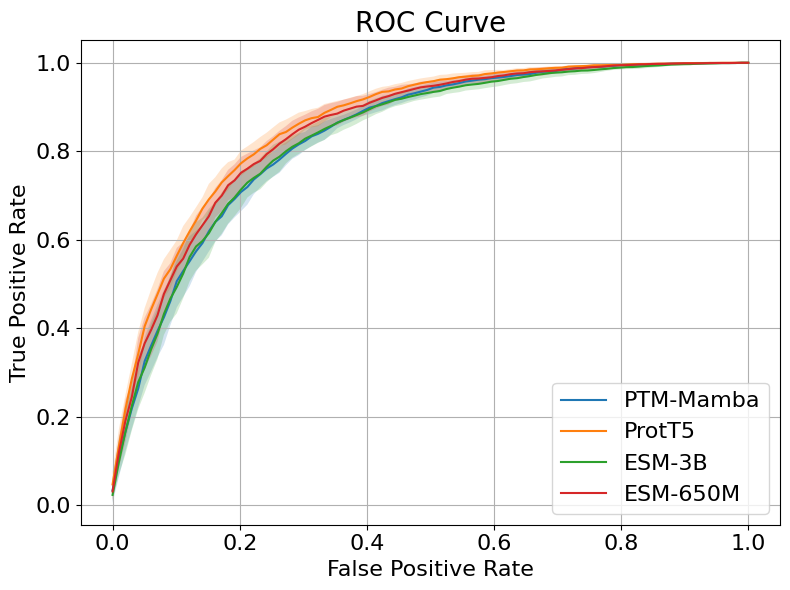

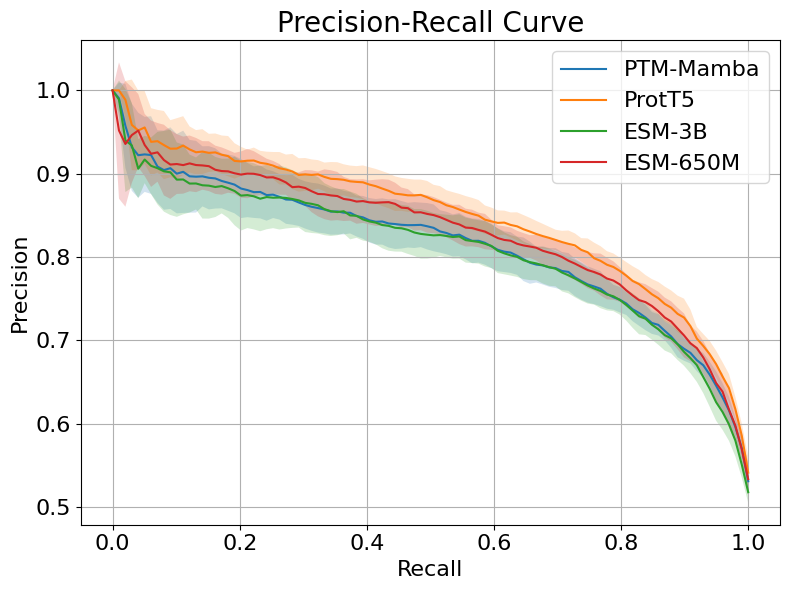

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import auc
from scipy.interpolate import interp1d
import pickle

def plot_mean_curve(curve_data, title, xlabel, ylabel):
    plt.figure(figsize=(8, 6))

    for model_name, curves in curve_data.items():
        mean_x = np.linspace(0, 1, 100)
        interpolated_ys = []

        for x, y in curves:
            interp_y = np.interp(mean_x, x, y)
            interpolated_ys.append(interp_y)

        mean_y = np.mean(interpolated_ys, axis=0)
        std_y = np.std(interpolated_ys, axis=0)

        plt.plot(mean_x, mean_y, label=f"{model_name}")
        plt.fill_between(mean_x, mean_y - std_y, mean_y + std_y, alpha=0.2)

    plt.title(title, fontsize=20)
    plt.xlabel(xlabel, fontsize=16)
    plt.ylabel(ylabel, fontsize=16)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.legend(fontsize=16, title_fontsize=16)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"{title.replace(' ', '_').lower()}_of_PLMs.pdf", format='pdf')
    plt.show()


def plot_mean_pr_curve(prc_data, title="Precision-Recall Curve"):
    plt.figure(figsize=(8, 6))
    mean_recall = np.linspace(0, 1, 100)

    for model_name, curves in prc_data.items():
        interpolated_precisions = []

        for recall, precision in curves:
            recall, precision = zip(*sorted(zip(recall, precision)))
            f = interp1d(recall, precision, bounds_error=False, fill_value=(precision[0], precision[-1]))
            interp_precision = f(mean_recall)
            interpolated_precisions.append(interp_precision)

        mean_precision = np.mean(interpolated_precisions, axis=0)
        std_precision = np.std(interpolated_precisions, axis=0)
        auc_score = auc(mean_recall, mean_precision)

        plt.plot(mean_recall, mean_precision, label=f"{model_name}")
        plt.fill_between(mean_recall, mean_precision - std_precision, mean_precision + std_precision, alpha=0.2)

    plt.title(title, fontsize=20)
    plt.xlabel("Recall", fontsize=16)
    plt.ylabel("Precision", fontsize=16)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.legend(fontsize=16, title_fontsize=16)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"{title.replace(' ', '_').lower()}_of_PLMs.pdf", format='pdf')
    plt.show()


# load the ROC and PRC data
with open('CSV results/roc_data.pkl', 'rb') as f:
    roc_data = pickle.load(f)

with open('CSV results/prc_data.pkl', 'rb') as f:
    prc_data = pickle.load(f)

# plot
plot_mean_curve(roc_data, "ROC Curve", "False Positive Rate", "True Positive Rate")
plot_mean_pr_curve(prc_data, "Precision-Recall Curve")

In [3]:
import pandas as pd
import numpy as np
# Load metrics from CSV files
metrics_mamba_df = pd.read_csv('CSV results/metrics_PTM-Mamba.csv')
metrics_t5_df = pd.read_csv('CSV results/metrics_ProtT5.csv')
metrics_esm_df = pd.read_csv('CSV results/metrics_ESM-3B.csv')
metrics_esm650_df = pd.read_csv('CSV results/metrics_ESM-650M.csv')

# Convert DataFrames to numpy arrays
metrics_mamba = metrics_mamba_df.to_numpy()
metrics_t5 = metrics_t5_df.to_numpy()
metrics_esm = metrics_esm_df.to_numpy()
metrics_esm650 = metrics_esm650_df.to_numpy()

metric_names = ["Accuracy", "MCC", "AUC", "AUPRC", "Precision", "Recall", "Specificity", "F1 Score"]
print(f"PTM-Mamba results:")
for i, (metric_name, metric_mean) in enumerate(zip(metric_names, metrics_mamba.mean(axis=0))):
    print(f"{metric_name}: {metric_mean:.4f} ± {metrics_mamba.std(axis=0)[i]:.4f}")

# print T5 results
print(f"\nPTM-T5 results:")
for i, (metric_name, metric_mean) in enumerate(zip(metric_names, metrics_t5.mean(axis=0))):
    print(f"{metric_name}: {metric_mean:.4f} ± {metrics_t5.std(axis=0)[i]:.4f}")

# print ESM results
print(f"\nPTM-ESM results:")
for i, (metric_name, metric_mean) in enumerate(zip(metric_names, metrics_esm.mean(axis=0))):
    print(f"{metric_name}: {metric_mean:.4f} ± {metrics_esm.std(axis=0)[i]:.4f}")

# print ESM650 results
print(f"\nPTM-ESM650 results:")
for i, (metric_name, metric_mean) in enumerate(zip(metric_names, metrics_esm650.mean(axis=0))):
    print(f"{metric_name}: {metric_mean:.4f} ± {metrics_esm650.std(axis=0)[i]:.4f}")


PTM-Mamba results:
Accuracy: 0.7561 ± 0.0154
MCC: 0.5142 ± 0.0309
AUC: 0.8367 ± 0.0129
AUPRC: 0.8147 ± 0.0197
Precision: 0.7589 ± 0.0236
Recall: 0.7598 ± 0.0498
Specificity: 0.7523 ± 0.0432
F1 Score: 0.7579 ± 0.0208

PTM-T5 results:
Accuracy: 0.7861 ± 0.0139
MCC: 0.5727 ± 0.0275
AUC: 0.8640 ± 0.0112
AUPRC: 0.8472 ± 0.0146
Precision: 0.7864 ± 0.0136
Recall: 0.7916 ± 0.0323
Specificity: 0.7804 ± 0.0209
F1 Score: 0.7886 ± 0.0169

PTM-ESM results:
Accuracy: 0.7634 ± 0.0128
MCC: 0.5280 ± 0.0252
AUC: 0.8345 ± 0.0158
AUPRC: 0.8101 ± 0.0202
Precision: 0.7564 ± 0.0214
Recall: 0.7782 ± 0.0307
Specificity: 0.7486 ± 0.0355
F1 Score: 0.7664 ± 0.0131

PTM-ESM650 results:
Accuracy: 0.7719 ± 0.0152
MCC: 0.5449 ± 0.0301
AUC: 0.8517 ± 0.0147
AUPRC: 0.8290 ± 0.0187
Precision: 0.7686 ± 0.0164
Recall: 0.7784 ± 0.0401
Specificity: 0.7655 ± 0.0276
F1 Score: 0.7727 ± 0.0195


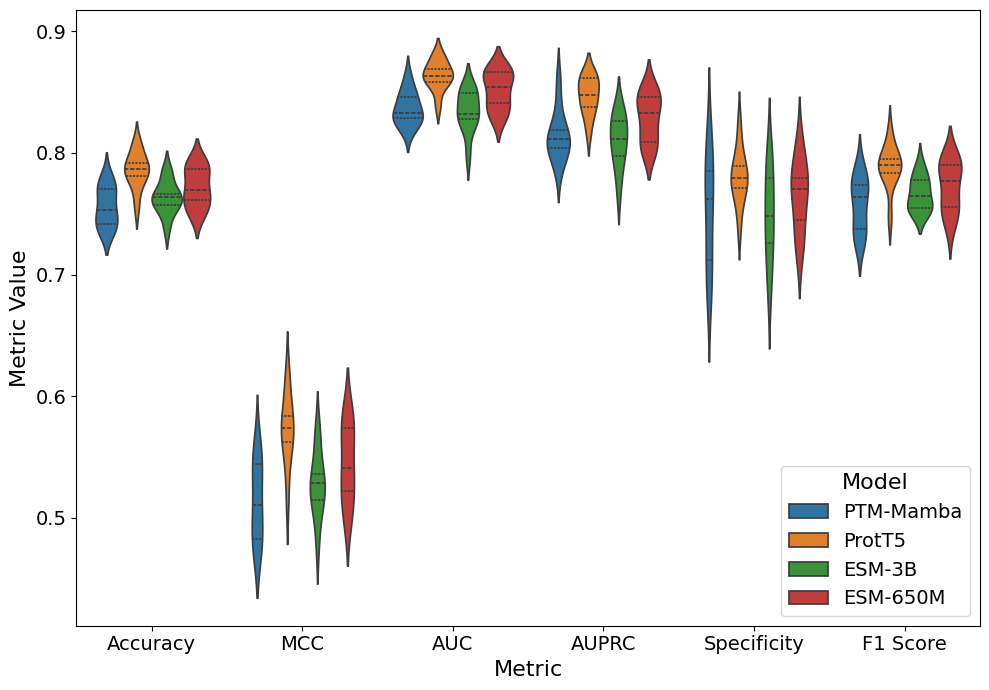

In [4]:
# violin plot for metrics of mamba and t5 in same figure
import matplotlib.pyplot as plt
import seaborn as sns

# Keep only selected metrics for plotting
selected_metrics = ['Accuracy', 'MCC', 'AUC', 'AUPRC', 'Specificity', 'F1 Score']

metrics_mamba_df = metrics_mamba_df[selected_metrics]
metrics_t5_df = metrics_t5_df[selected_metrics]
metrics_esm_df = metrics_esm_df[selected_metrics]
metrics_esm650_df = metrics_esm650_df[selected_metrics]

# Prepare data for plotting in long format
metrics_mamba_long = metrics_mamba_df.melt(var_name='Metric', value_name='Value')
metrics_mamba_long['Model'] = 'PTM-Mamba'
metrics_t5_long = metrics_t5_df.melt(var_name='Metric', value_name='Value')
metrics_t5_long['Model'] = 'ProtT5'
metrics_esm_long = metrics_esm_df.melt(var_name='Metric', value_name='Value')
metrics_esm_long['Model'] = 'ESM-3B'
metrics_esm650_long = metrics_esm650_df.melt(var_name='Metric', value_name='Value')
metrics_esm650_long['Model'] = 'ESM-650M'

metrics_long = pd.concat([metrics_mamba_long, metrics_t5_long, metrics_esm_long, metrics_esm650_long], ignore_index=True)

plt.figure(figsize=(10, 7))
sns.violinplot(x='Metric', y='Value', hue='Model', data=metrics_long, inner="quartile")
plt.ylabel('Metric Value', fontsize=16)
plt.xlabel('Metric', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(title='Model', loc='lower right', fontsize=14, title_fontsize=16)
plt.tight_layout()
plt.savefig('Different_PLM_results_comparison.pdf', format='pdf')
plt.show()


